In [107]:
import numpy as np
import pandas as pd
import seaborn as sns
import math

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

from yellowbrick.target import FeatureCorrelation

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SelectFdr, f_regression

##### Houses DataBase

In [59]:
houses_size = np.array([30, 39, 49, 60])

houses_price = np.array([57000, 69000, 77000, 90000])

houses_dataset = pd.DataFrame({"size": houses_size, "price": houses_price})

houses_dataset.head()

,size,price
0,30,57000
1,39,69000
2,49,77000
3,60,90000


##### Manual mode

In [60]:
houses_size_mean = houses_dataset["size"].mean()
houses_price_mean = houses_dataset["price"].mean()
houses_size_std = houses_dataset["size"].std()
houses_price_std = houses_dataset["price"].std()

houses_size_mean, houses_price_mean, houses_size_std, houses_price_std

(44.5, 73250.0, 12.922847983320086, 13865.424623862047)

In [61]:
houses_dataset["diff"] = (houses_dataset["size"] - houses_size_mean) * (
    houses_dataset["price"] - houses_price_mean
)

houses_dataset

,size,price,diff
0,30,57000,235625.0
1,39,69000,23375.0
2,49,77000,16875.0
3,60,90000,259625.0


In [62]:
houses_sum_diff = houses_dataset["diff"].sum()

houses_sum_diff

535500.0

In [63]:
houses_cov = houses_sum_diff / (len(houses_dataset) - 1)

houses_cov

178500.0

In [64]:
houses_cor = houses_cov / (houses_size_std * houses_price_std)

houses_cor

0.9962006267707775

<Axes: xlabel='size', ylabel='price'>

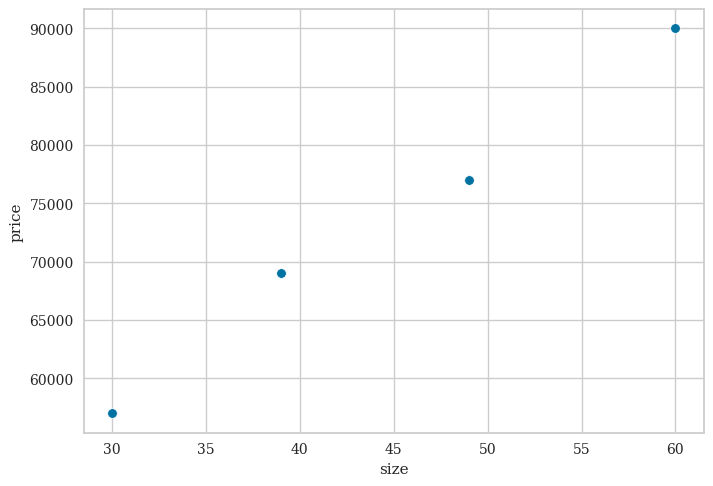

In [65]:
sns.scatterplot(data=houses_dataset, x="size", y="price")

In [66]:
houses_determination = houses_cor**2

houses_determination

0.9924156887784898

##### Easy mode

In [67]:
np.cov(houses_size, houses_price)

array([[1.6700e+02, 1.7850e+05],
       [1.7850e+05, 1.9225e+08]])

In [68]:
np.cov(houses_size, houses_price)[0][1]

178500.0

In [69]:
houses_dataset.cov()

,size,price,diff
size,167.0,178500.0,1.850000e+05
price,178500.0,192250000.0,1.612500e+08
diff,185000.0,161250000.0,1.735512e+10


In [70]:
np.corrcoef(houses_size, houses_price)

array([[1.        , 0.99620063],
       [0.99620063, 1.        ]])

In [71]:
houses_dataset.corr()

,size,price,diff
size,1.000000,0.996201,0.108667
price,0.996201,1.000000,0.088278
diff,0.108667,0.088278,1.000000


##### Exercise

In [72]:
houses_dataset = pd.read_csv("data/house_prices.csv")

houses_dataset.drop(
    columns=["id", "date", "sqft_living", "sqft_lot"], axis=1, inplace=True
)

houses_dataset.head()

,price,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [73]:
houses_dataset.corr()

,price,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
price,1.000000,0.308350,0.525138,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,0.308350,1.000000,0.515884,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,0.525138,0.515884,1.000000,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
floors,0.256794,0.175429,0.500653,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,0.266369,-0.006582,0.063744,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.397293,0.079532,0.187737,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,0.036362,0.028472,-0.124982,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406
grade,0.667434,0.356967,0.664983,0.458183,0.082775,0.251321,-0.144674,1.000000,0.755923,0.168392,0.446963,0.014414,-0.184862,0.114084,0.198372,0.713202,0.119248
sqft_above,0.605567,0.477600,0.685342,0.523885,0.072075,0.167649,-0.158214,0.755923,1.000000,-0.051943,0.423898,0.023285,-0.261190,-0.000816,0.343803,0.731870,0.194050
sqft_basement,0.323816,0.303093,0.283770,-0.245705,0.080588,0.276947,0.174105,0.168392,-0.051943,1.000000,-0.133124,0.071323,0.074845,0.110538,-0.144765,0.200355,0.017276


<Axes: xlabel='sqft_living15', ylabel='price'>

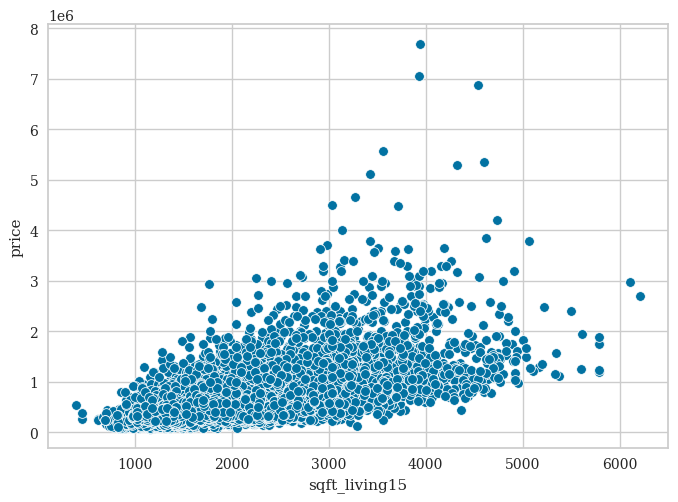

In [74]:
sns.scatterplot(
    x=houses_dataset["sqft_living15"],
    y=houses_dataset["price"],
)

<Axes: xlabel='grade', ylabel='price'>

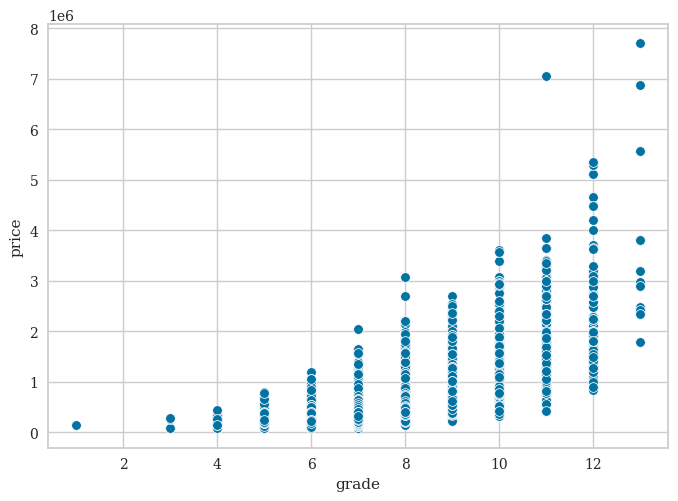

In [75]:
sns.scatterplot(
    x=houses_dataset["grade"],
    y=houses_dataset["price"],
)

<Axes: xlabel='long', ylabel='price'>

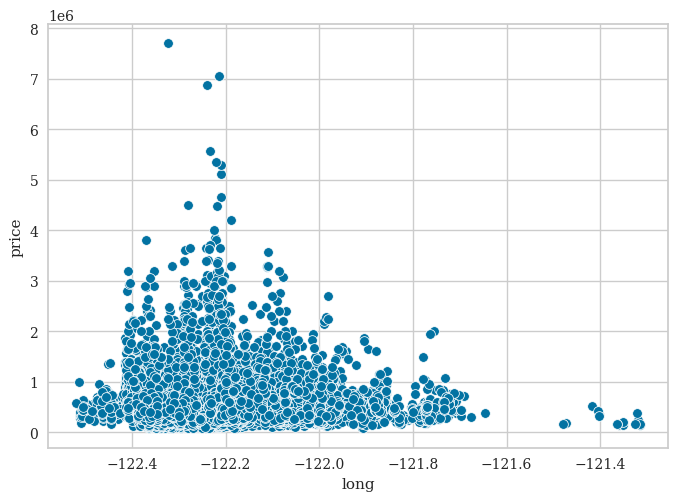

In [76]:
sns.scatterplot(
    x=houses_dataset["long"],
    y=houses_dataset["price"],
)

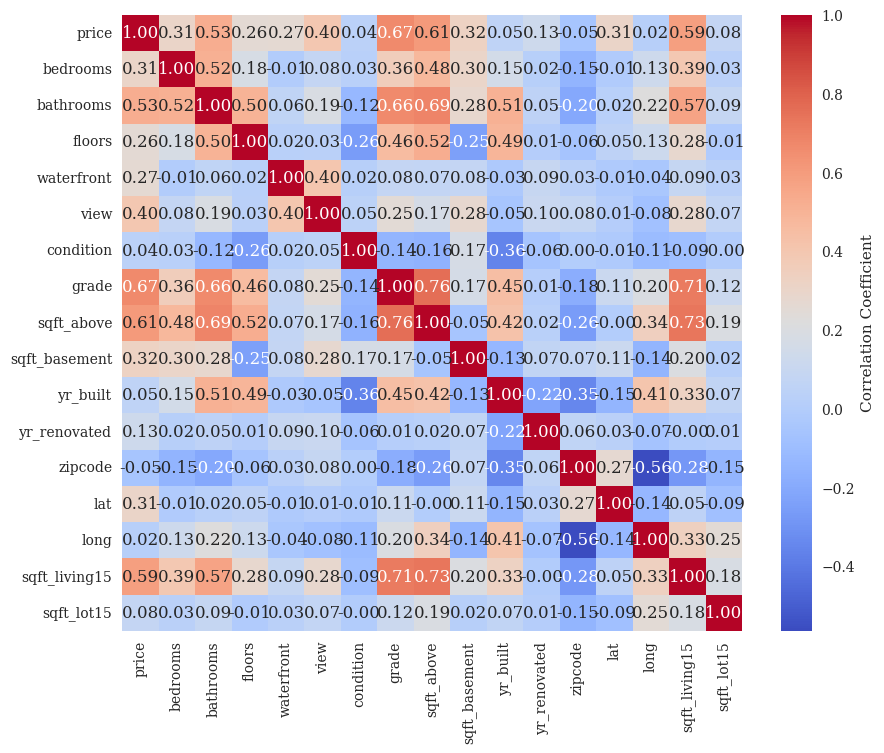

In [77]:
fig, ax = plt.subplots(figsize=(10, 8))

ax = sns.heatmap(
    houses_dataset.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={"label": "Correlation Coefficient"},
)

##### Yellowbrick

In [78]:
houses_dataset.columns

Index(['price', 'bedrooms', 'bathrooms', 'floors', 'waterfront', 'view',
       'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built',
       'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15',
       'sqft_lot15'],
      dtype='object')

In [79]:
houses_dataset.iloc[:, 0:16]

,price,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15
0,221900.0,3,1.00,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340
1,538000.0,3,2.25,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690
2,180000.0,2,1.00,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720
3,604000.0,4,3.00,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360
4,510000.0,3,2.00,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530
21609,400000.0,4,2.50,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830
21610,402101.0,2,0.75,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020
21611,400000.0,3,2.50,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410


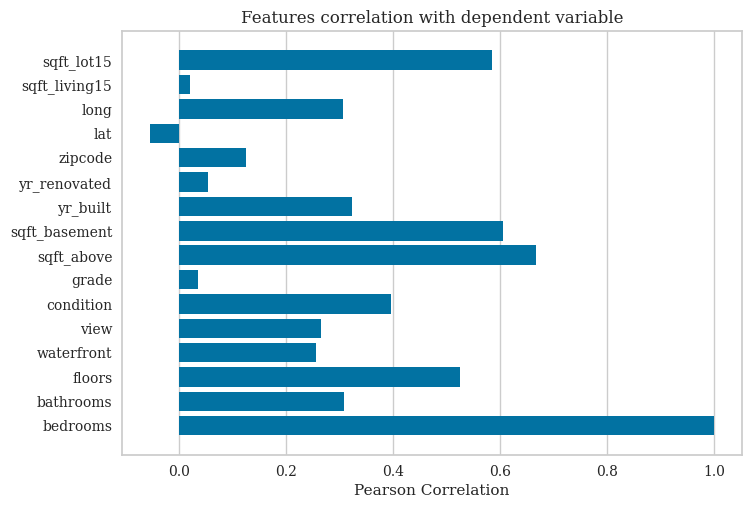

<Axes: title={'center': 'Features correlation with dependent variable'}, xlabel='Pearson Correlation'>

In [80]:
corr_graph = FeatureCorrelation(
    labels=houses_dataset.columns[1:],
)

corr_graph.fit(houses_dataset.iloc[:, 0:16].values, houses_dataset.iloc[:, 0].values)

corr_graph.show()

##### Linear regression

In [81]:
houses_dataset = pd.read_csv("data/house_prices.csv")

houses_dataset.drop(columns=["id", "date"], axis=1, inplace=True)

houses_dataset.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


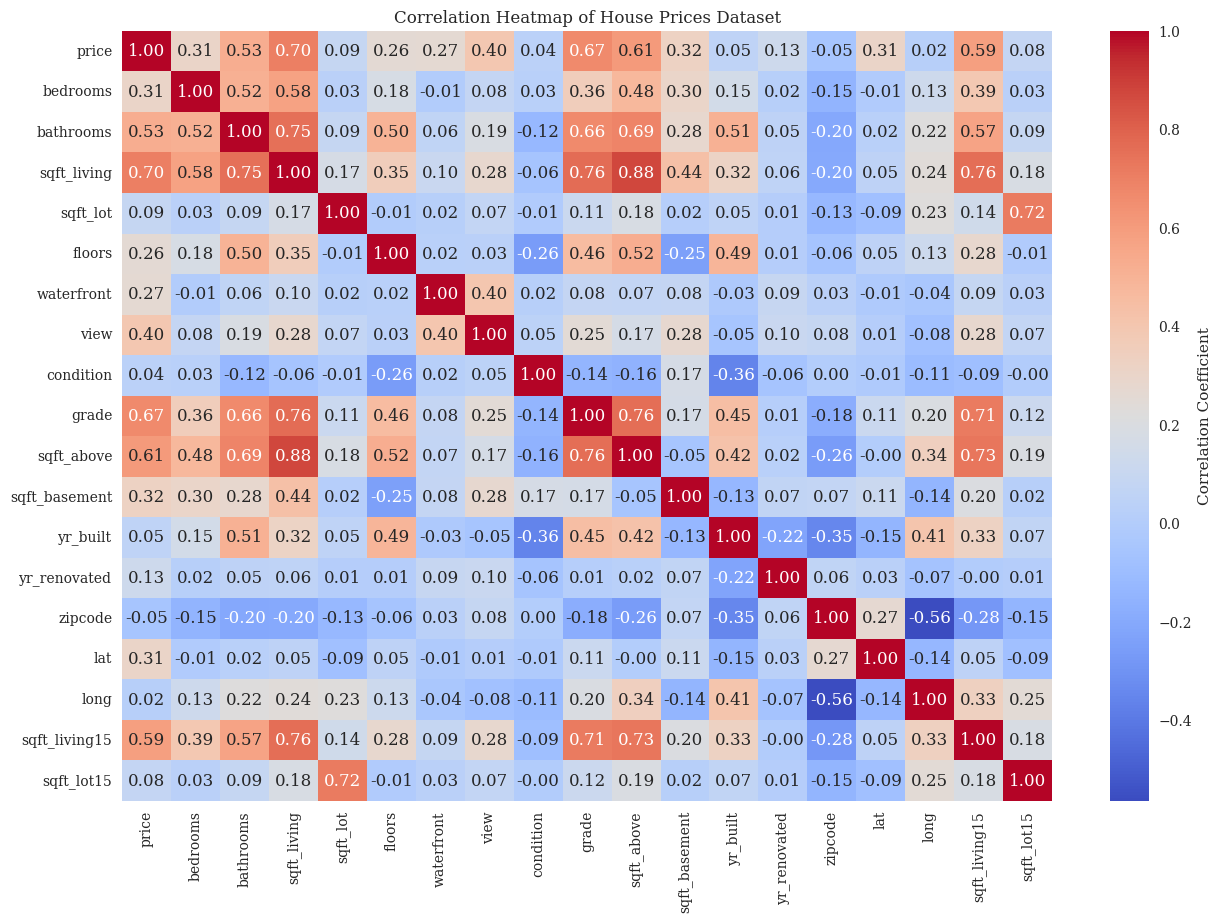

In [82]:
fig, ax = plt.subplots(figsize=(15, 10))

ax = sns.heatmap(
    houses_dataset.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar_kws={"label": "Correlation Coefficient"},
)

plt.title("Correlation Heatmap of House Prices Dataset")

plt.show()

In [83]:
math.pow(0.7, 2)  # sqft_living X Price correlation

0.48999999999999994

In [84]:
X = np.array(houses_dataset["sqft_living"]).reshape(-1, 1)
y = np.array(houses_dataset["price"])

X.shape, y.shape

((21613, 1), (21613,))

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((17290, 1), (4323, 1), (17290,), (4323,))

In [86]:
regression_model = LinearRegression()

regression_model.fit(X_train, y_train)

LinearRegression()

In [87]:
regression_model.intercept_, regression_model.coef_

(-41999.18603993731, array([279.55477932]))

In [88]:
(
    regression_model.intercept_ + regression_model.coef_ * 770
)  # Price(180k) prediction for 770 sqft

array([173257.99403282])

In [89]:
regression_model.predict(np.array([[770]]))  # Price(180k) prediction for 770 sqft

array([173257.99403282])

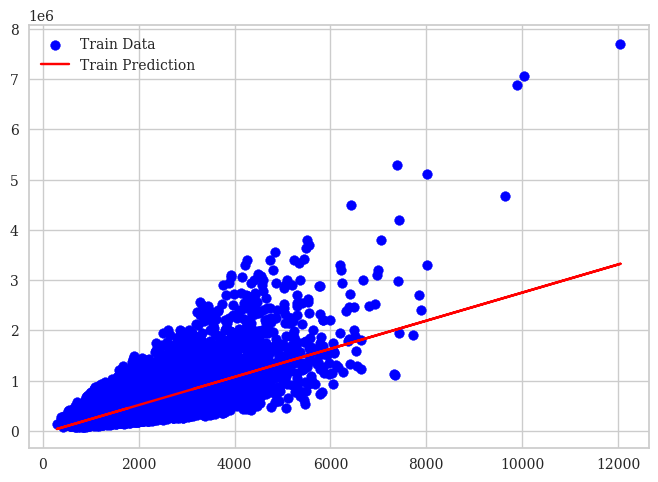

In [90]:
plt.scatter(X_train, y_train, color="blue", label="Train Data")
plt.plot(
    X_train, regression_model.predict(X_train), color="red", label="Train Prediction"
)
plt.legend()

In [91]:
regression_model.score(X_train, y_train)  # Train R^2

0.49238383875829517

In [92]:
regression_model.score(X_test, y_test)  # R^2 score for test data

0.49406905389089006

##### Error metrics

In [93]:
prediction = regression_model.predict(X_test)

prediction, y_test

(array([ 536679.20714266,  768709.67397433, 1011922.33197861, ...,
         638437.14681341,  586999.06741941,  676456.59680029]),
 array([ 365000.,  865000., 1038000., ...,  285000.,  605000.,  356500.]))

In [94]:
mean_absolute_error(y_test, prediction), mean_squared_error(
    y_test, prediction
), math.sqrt(mean_squared_error(y_test, prediction))

(177867.54034434858, 76484977061.77612, 276559.1746114674)

##### Multiple linear regression

In [95]:
houses_dataset.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [96]:
X = np.array(houses_dataset.iloc[:, [2, 3, 9, 10]].values)

X

array([[1.00e+00, 1.18e+03, 7.00e+00, 1.18e+03],
       [2.25e+00, 2.57e+03, 7.00e+00, 2.17e+03],
       [1.00e+00, 7.70e+02, 6.00e+00, 7.70e+02],
       ...,
       [7.50e-01, 1.02e+03, 7.00e+00, 1.02e+03],
       [2.50e+00, 1.60e+03, 8.00e+00, 1.60e+03],
       [7.50e-01, 1.02e+03, 7.00e+00, 1.02e+03]])

In [97]:
y = np.array(houses_dataset["price"].values)

y

array([221900., 538000., 180000., ..., 402101., 400000., 325000.])

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((17290, 4), (4323, 4), (17290,), (4323,))

In [99]:
regression_model = LinearRegression()

regression_model.fit(X_train, y_train)

regression_model.score(X_train, y_train), regression_model.score(X_test, y_test)

(0.5422391122817639, 0.5474386197329253)

In [100]:
mean_absolute_error(y_test, regression_model.predict(X_test)), mean_squared_error(
    y_test, regression_model.predict(X_test)
), math.sqrt(mean_squared_error(y_test, regression_model.predict(X_test)))

(164587.58612465937, 68416741563.20139, 261565.94113760567)

(array([2., 0., 0., 0., 0., 1., 0., 0., 0., 1.]),
 array([   3. ,  198.7,  394.4,  590.1,  785.8,  981.5, 1177.2, 1372.9,
        1568.6, 1764.3, 1960. ]),
 <BarContainer object of 10 artists>)

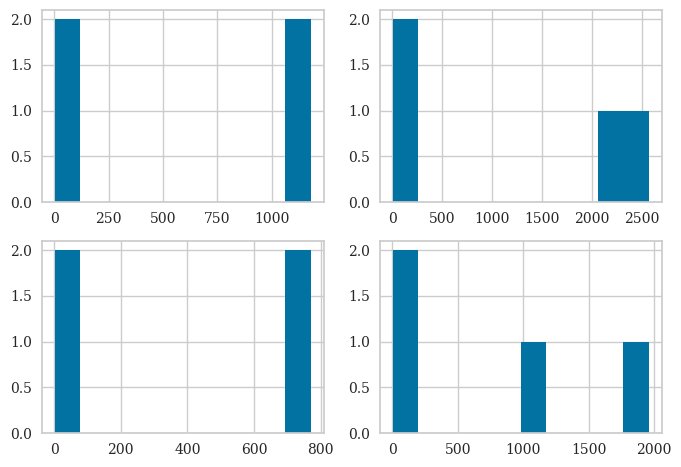

In [101]:
f, ax = plt.subplots(2, 2)
ax[0, 0].hist(X[0])
ax[0, 1].hist(X[1])
ax[1, 0].hist(X[2])
ax[1, 1].hist(X[3])

(array([1.9021e+04, 2.1480e+03, 3.1600e+02, 9.0000e+01, 2.6000e+01,
        4.0000e+00, 4.0000e+00, 1.0000e+00, 1.0000e+00, 2.0000e+00]),
 array([  75000.,  837500., 1600000., 2362500., 3125000., 3887500.,
        4650000., 5412500., 6175000., 6937500., 7700000.]),
 <BarContainer object of 10 artists>)

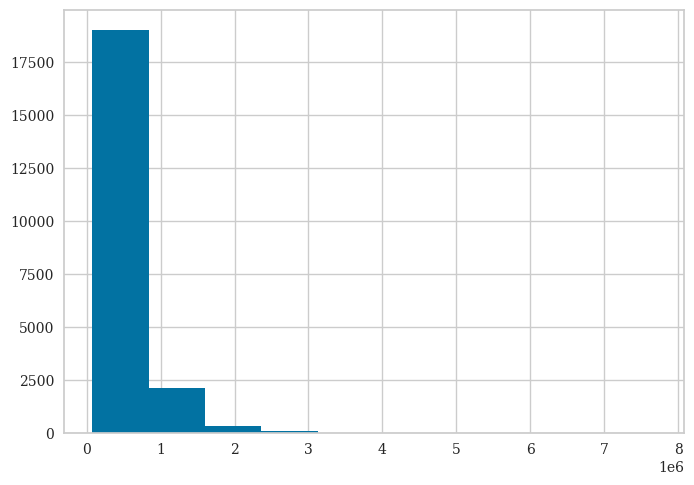

In [102]:
plt.hist(y)

(array([6.300e+01, 5.330e+02, 3.977e+03, 7.183e+03, 6.345e+03, 2.541e+03,
        7.330e+02, 1.930e+02, 3.800e+01, 7.000e+00]),
 array([11.22524339, 11.68839214, 12.15154089, 12.61468964, 13.07783839,
        13.54098714, 14.00413589, 14.46728464, 14.93043339, 15.39358214,
        15.85673089]),
 <BarContainer object of 10 artists>)

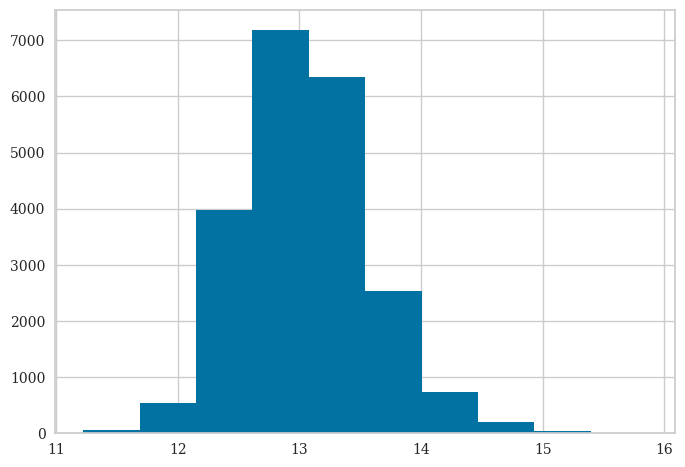

In [103]:
y = np.log(y)

plt.hist(y)

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

regression_model = LinearRegression()

regression_model.fit(X_train, y_train)

regression_model.score(X_train, y_train), regression_model.score(X_test, y_test)

(0.5621078983042502, 0.5736441443868046)

##### Exercise

In [ ]:
dataset = houses_dataset.drop(labels=["sqft_living15", "sqft_lot15"], axis=1)

dataset.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045


In [106]:
X = dataset.iloc[:, 1:16].values
y = dataset.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

regression_model = LinearRegression()

regression_model.fit(X_train, y_train)

regression_model.score(X_train, y_train), regression_model.score(X_test, y_test)

(0.6954105960380901, 0.6941186197955)

##### Attribute selection

In [110]:
selection = SelectFdr(
    f_regression,
    alpha=0.0,
)

X_new = selection.fit_transform(X, y)

X_new.shape, X.shape

((21613, 9), (21613, 15))

In [111]:
selection.pvalues_

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 7.97250451e-040,
       1.58101007e-322, 0.00000000e+000, 0.00000000e+000, 8.93565406e-008,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 1.92987281e-015,
       1.02134789e-077, 5.01105043e-015, 0.00000000e+000])

In [112]:
selection.get_support()

array([ True,  True,  True, False, False,  True,  True, False,  True,
        True,  True, False, False, False,  True])

In [114]:
dataset.iloc[:, 1:16].columns[selection.get_support()]

Index(['bedrooms', 'bathrooms', 'sqft_living', 'waterfront', 'view', 'grade',
       'sqft_above', 'sqft_basement', 'lat'],
      dtype='object')

In [115]:
X_train, X_test, y_train, y_test = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

regression_model = LinearRegression()

regression_model.fit(X_train, y_train)

regression_model.score(X_train, y_train), regression_model.score(X_test, y_test)

(0.655227806395245, 0.660796414061688)